In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import openflash as of
from scipy.special import hankel1e 
import capytaine as cpt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'


In [14]:
r1 = 2.5/2 # bottom radius [m]
r2 = 8.4/2 # top radius [m]

d1 = 14.45 # draft [m]
d2 = 14.45-7.32 # vertical distance to bottom of slant [m]
d3 = 14.45-7.32-5.08 # vertical distance to top of slant [m]



In [15]:
def CorPower_geom(r1,r2,d1,d2,d3,num_subdivs):

    d_list = np.linspace(d2,d3,num_subdivs)
    a_list = np.linspace(r1,r2,num_subdivs)

    d_list[0] = d1

    return d_list, a_list

In [16]:
def compute_hydrostatics(a_list, d_list, rho, g):
    hydrostatic_stiffness = 0
    mass = 0

    for i in range(len(a_list)):    
        if i==0:
            area_i = np.pi*a_list[i]**2
        else:
            area_i = np.pi*(a_list[i]**2-a_list[i-1]**2)
        volume_i = area_i * d_list[i]

        hydrostatic_stiffness += rho * g * area_i
        mass += rho * volume_i 

    return hydrostatic_stiffness, mass 

In [17]:
def compute_CorPower_data(r1,r2,d1,d2,d3,show_geom=False,save_data=True):

    # Settings
    rho=1000
    g=9.81
    omega_sweep = np.linspace(0.4,1.5,10)
    h = 100            # Water Depth (m)
    heaving_list = True 
    num_subdivs=10
    truncastion_order = 50

    # Generate correct input
    d_list, a_list = CorPower_geom(r1,r2,d1,d2,d3,num_subdivs)
    num_regions = len(d_list)
    NMK = [truncastion_order] * (num_regions+1)

    # Show plot of geom
    if show_geom:
        fig, ax = plt.subplots()
        for i, (a, d) in enumerate(zip(a_list,d_list)):
            if i==0:
                a_in=0 
                ax.fill([a_in,a,a,a_in],[-d,-d,0,0], color=[0.7,0.7,0.7], edgecolor='black', label='Approximated geometry')       
            else:
                a_in=a_list[i-1]
                ax.fill([a_in,a,a,a_in],[-d,-d,0,0], color=[0.7,0.7,0.7], edgecolor='black')
        ax.plot([0,r1,r1,r2,r2],[-d1,-d1,-d2,-d3,0],color="red",label="True outline")
        ax.set_aspect('equal')
        ax.legend(loc='best', frameon=False)
        ax.set_xlim([0, -np.min(-d_list)])
        ax.set_ylim([np.min(-d_list),0])
        ax.set_xlabel("x [m]")
        ax.set_ylabel("z [m]")
        ax.set_title("CorPower WEC profile")
        # fig.savefig("CorPower_profile", format='pdf', dpi=300)

    # Single Body
    bodies_sweep = []
    body = of.SteppedBody(
        a=np.array(a_list),
        d=np.array(d_list),
        slant_angle= np.zeros_like(a_list),
        heaving=heaving_list
    )
    bodies_sweep.append(body)

    # Create arrangement
    arrangement_sweep = of.ConcentricBodyGroup(bodies_sweep)

    # Create geometry
    geometry_sweep = of.BasicRegionGeometry(
        body_arrangement=arrangement_sweep,
        h=h,
        NMK=NMK
    )

    # Create the MEEMProblem instance
    problem = of.MEEMProblem(geometry_sweep)

    # Set the frequencies for the sweep
    problem.set_frequencies(omega_sweep)

    # Initialize a new MEEM Engine for this problem
    engine = of.MEEMEngine(problem_list=[problem])

    # Solve
    results = engine.run_and_store_results(0)
    hydrodynamic_dataset = results.get_results()

    # Export
    if save_data:
        results.export_to_netcdf("hydrodynamic_data.nc")

    # Hydrostatics
    hydrostatic_stiffness, mass = compute_hydrostatics(a_list, d_list, rho, g)
    hydrostatic_dataset = [hydrostatic_stiffness, mass]


    return hydrodynamic_dataset, hydrostatic_dataset

Hydrodynamic coefficients stored in xarray dataset.
Potentials stored in xarray dataset (batched across frequencies/modes).


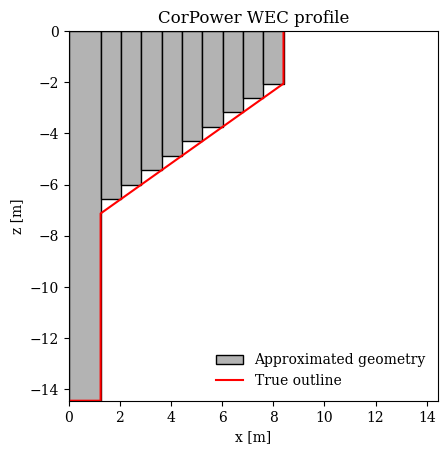

In [ ]:
hydrodynamic_dataset, hydrostatic_dataset = compute_CorPower_data(r1,r2,d1,d2,d3,show_geom=True,save_data=True)

In [24]:
hydrodynamic_dataset

<xarray.Dataset> Size: 355kB
Dimensions:             (frequency: 10, mode_i: 1, mode_j: 1,
                         c_vector_index: 950, harmonics: 100, domain_name: 11,
                         modes: 1)
Coordinates:
  * frequency           (frequency) float64 80B 0.4 0.5222 0.6444 ... 1.378 1.5
  * mode_i              (mode_i) int64 8B 0
  * mode_j              (mode_j) int64 8B 0
  * c_vector_index      (c_vector_index) int64 8kB 0 1 2 3 4 ... 946 947 948 949
  * harmonics           (harmonics) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
  * domain_name         (domain_name) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * modes               (modes) int64 8B 0
Data variables:
    added_mass          (frequency, mode_i, mode_j) float64 80B 1.219e+06 ......
    damping             (frequency, mode_i, mode_j) float64 80B 1.106e+05 ......
    excitation_force    (frequency, mode_i) float64 80B 1.893e+06 ... 4.121e+05
    excitation_phase    (frequency, mode_i) float64 80B -0.02341 ... -1.416
    c_vector            (frequency, mode_i, c_vector_index) complex128 152kB ...
    potentials_real     (frequency, modes, domain_name, harmonics) float64 88kB ...
    potentials_imag     (frequency, modes, domain_name, harmonics) float64 88kB ...
    potential_r_coords  (domain_name, harmonics) float64 9kB 0.0 0.0 ... nan nan
    potential_z_coords  (domain_name, harmonics) float64 9kB 0.0 0.0 ... nan nan

In [ ]:
# NEXT STEP, unpack and repack data to match capytaine's structure exactly
added_mass_data = hydrodynamic_dataset.added_mass.values

array([[[1219149.25850458]],

       [[1153360.28262683]],

       [[1036318.83206095]],

       [[ 913905.11260043]],

       [[ 805833.35462127]],

       [[ 719402.64647196]],

       [[ 656130.50220627]],

       [[ 614180.04420339]],

       [[ 590121.28135792]],

       [[ 580020.17925262]]])